# Spotify Global Top 50 — Phase 4 Final Analysis

**Course:** IN5304 Data Science in the Wild

**Authors:** Zoe Tseng, Charlotte Lin, Irene Wu, Serene Tsai

**Repository:** [Irene-Wu-1002/Spotify-Trend-Analyzer](https://github.com/Irene-Wu-1002/Spotify-Trend-Analyzer)

## 1. Introduction
Spotify’s **Global Weekly Top 50** is one of the most visible signals of mainstream music consumption in the world. Understanding *why* certain songs persist on the chart — while others vanish in a week — is valuable to artists, labels, A&R teams, and music platforms. The conventional industry view emphasises **brand power** (label backing, artist following, marketing budget). The data-science view increasingly emphasises **measurable acoustic signal** (energy, tempo, brightness, harmonic stability). We use the chart itself as a real-world arena to test which view holds up.

### Research questions

Our central research question is: **What contributes to a song’s chart performance on Spotify?** We focus on analyzing this question from a few perspectives: artist collaborations, label power, and audio feature synergy. 

The following are the specific data analysis questions :

1. **Collaboration & longevity** — Do songs with featured artists stay on the Global Top 50 longer than solo tracks, after controlling for first-week popularity?
2. **Label power & longevity** — Do tracks released under one of the “Big-3” major labels (Universal, Sony, Warner) stay on the chart longer than independent releases, after controlling for first-week popularity *and* audio characteristics?
3. **Audio synergy & virality** — Does the **interaction** of energy and spectral brightness predict whether a song peaks inside the Top 15 (a “viral” tier), beyond either feature alone?

### Why these questions matter

- The collaboration question maps to a debate in the industry about whether features are a longevity strategy or just a launch tactic ([Music Business Worldwide, 2023](https://www.musicbusinessworldwide.com/)).
- The label question speaks to ongoing concerns about consolidation: the IFPI estimates the Big-3 control roughly two-thirds of recorded music revenue ([IFPI Global Music Report, 2023](https://www.ifpi.org/our-industry/industry-data/)).
- The viral / audio-synergy question connects to an established line of research on the acoustic correlates of popularity (e.g. Interiano et al., *Royal Society Open Science*, 2018).

## 2. Data Description

- **Primary source — Spotify Charts (Global · Weekly · Top 50).** One row per (track × chart week) from 2021-01-07 through 2026-02-19. Fields used: `rank`, `uri`, `artist_names`, `track_name`, `source` (record label), `peak_rank`, `previous_rank`, `weeks_on_chart`, `streams`, `date`.
- **Audio features (extracted in-house with `librosa` from YouTube audio).** Per unique track: `tempo`, `energy`, `zero_crossing_rate`, `spectral_centroid`, `spectral_rolloff`, `mfcc_1`, `mfcc_2`, `chroma_mean`, `chroma_std`. Spotify’s `audio_analysis` endpoint was deprecated in late 2024, so we built our own pipeline.
- **Artist enrichment.** `artist_count` and `collaboration_type` (binary, derived from `artist_names`); `monthly_listeners` (scraped from [kworb.net](https://kworb.net/spotify/listeners.html)); `popularity_score` (Groover’s public Spotify popularity index).
- **Label enrichment.** Each `source` (label string) hand-labelled into one of three classes: `0 = Big-3 parent`, `1 = Big-3 subsidiary`, `2 = independent`. Stored in `data/raw/raw_unique_source_labeled.csv`.

### Why these columns matter for our research questions

| RQ | Key columns |
|----|-------------|
| H1 — Collaborations & longevity | `collaboration_type`, `artist_count`, `weeks_on_chart`, `streams_first_week`, `popularity_score` |
| H2 — Label power & longevity | `major_label` (derived), `weeks_on_chart`, `streams_first_week`, all 9 audio features |
| H3 — Audio synergy & virality | `energy`, `spectral_centroid`, their interaction, `peak_rank` (binarised at 15) |

### Links

- **Full Phase 2 data description (PDF):** [`docs/phase2_data_description.pdf`](https://github.com/Irene-Wu-1002/Spotify-Trend-Analyzer/blob/main/docs/phase2_data_description.pdf)
- **Raw chart data (per-week CSVs):** [`data/raw/`](https://github.com/Irene-Wu-1002/Spotify-Trend-Analyzer/tree/main/data/raw)
- **Cleaned & merged dataset used in this notebook:** [`data/processed/processed_chart_tracks_enriched_features.csv`](https://github.com/Irene-Wu-1002/Spotify-Trend-Analyzer/blob/main/data/processed/processed_chart_tracks_enriched_features.csv)

## 3. Data Collection & Cleaning

We collected weekly Global Top 50 rankings from `charts.spotify.com` using a Selenium-based scraper that authenticates with cached cookies, then iterates Mondays from 2021-01-07 through 2026-02-19 and downloads each week’s CSV. Weekly CSVs were concatenated into a single chart-week table. For each unique track URI we then fetched the corresponding YouTube audio with `yt-dlp` and computed the nine `librosa` audio features listed above; these were merged back onto the chart table by `uri`. Finally, we enriched the table with artist-level features (`artist_count`, `collaboration_type`, `monthly_listeners`, `popularity_score`) and a hand-labelled record-label class (`major_label`).

The full pipeline lives in three notebooks in this repo, in order:

1. [`notebooks/01_scrape_weekly_charts.ipynb`](https://github.com/Irene-Wu-1002/Spotify-Trend-Analyzer/blob/main/notebooks/01_scrape_weekly_charts.ipynb) — Selenium scraper for `charts.spotify.com`.
2. [`notebooks/02_extract_audio_features.ipynb`](https://github.com/Irene-Wu-1002/Spotify-Trend-Analyzer/blob/main/notebooks/02_extract_audio_features.ipynb) — `yt-dlp` + `librosa` audio feature extraction.
3. [`notebooks/03_enrich_artist_features.ipynb`](https://github.com/Irene-Wu-1002/Spotify-Trend-Analyzer/blob/main/notebooks/03_enrich_artist_features.ipynb) — kworb scrape, Groover popularity, label labelling.

The output of that pipeline — `data/processed/processed_chart_tracks_enriched_features.csv` — is the **only** file imported below.

### Differences vs. Phase 2

- Added the `monthly_listeners` (kworb) and `popularity_score` (Groover) columns; both were noted as "to-do" in Phase 2.
- Hand-labelled every distinct `source` string into the `major_label` 3-class scheme (`raw_unique_source_labeled.csv`); Phase 2 only had the raw label string.
- Renamed and re-derived `collaboration_type` so that `0 = solo`, `1 = collab`.
- Added a song-level aggregation step (one row per `uri`) used by H1 and H2 to compute `streams_first_week`, `entry_rank_in_top50`, and `total_weeks_on_chart`.

## 4. Preregistration Statements

Each preregistration was filed in Phase 3. Hypotheses, planned models, and decision rules are restated verbatim below; the only modification is to add controls that TA feedback flagged as missing (`popularity_score`, `previous_rank`).

### H1 — Collaborations & longevity

**Hypothesis.** Songs with artist collaborations exhibit greater chart longevity than solo tracks, even after controlling for first-week popularity and artist characteristics.

**Why we believe this.** Features expose a track to multiple fanbases simultaneously (e.g. Bad Bunny × JHAYCO on *DÁKITI*). Industry coverage of the 2020–2023 chart era highlights a steady rise in multi-artist credits among year-end #1s ([Billboard, 2023](https://www.billboard.com/)).

**Model.** OLS:

`total_weeks_on_chart ~ collaboration_type + streams_first_week + entry_rank_in_top50 + popularity_score + previous_rank`

**Decision rule.** Reject H0 if the coefficient on `collaboration_type` is positive and `p < 0.05`.

### H2 — Label power & longevity

**Hypothesis.** Songs released under major labels have greater chart longevity than independent releases, even after controlling for first-week popularity *and* musical characteristics.

**Why we believe this.** The Big-3 majors control ~two-thirds of recorded-music revenue and dominate playlist real-estate ([IFPI, 2023](https://www.ifpi.org/our-industry/industry-data/)). If label power matters, it should show up after audio is controlled for.

**Model.** OLS:

`total_weeks_on_chart ~ label_big3_parent + label_big3_subsidiary + streams_first_week + entry_rank_in_top50 + popularity_score + previous_rank + tempo + energy + spectral_centroid + spectral_rolloff + mfcc_1 + mfcc_2 + chroma_mean + chroma_std`

Independent releases are the baseline.

**Decision rule.** Reject H0 if **either** Big-3 coefficient is positive with `p < 0.05`.

### H3 — Audio synergy & virality

**Hypothesis.** The likelihood of a song reaching the Top 15 (a “viral” tier) is significantly higher when **specific levels of energy and spectral brightness combine**, rather than the independent effect of either feature alone.

**Why we believe this.** Interiano et al. (*Royal Society Open Science*, 2018) showed that successful pop tracks cluster on a non-additive ridge in the energy × brightness plane.

**Model.** Logistic regression:

`P(viral=1) ~ energy + spectral_centroid + (energy × spectral_centroid) + popularity_score + previous_rank`

with `viral = 1 if peak_rank ≤ 15 else 0`.

**Decision rule.** Reject H0 if the interaction coefficient is significantly different from zero (`p < 0.05`).

## 5. Data Analysis & Evaluation of Significance

### 5.0 Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110

DATA = "../data/processed/processed_chart_tracks_enriched_features.csv"
LABELS = "../data/raw/raw_unique_source_labeled.csv"

df = pd.read_csv(DATA, parse_dates=["date"])
print(f"Chart-week rows : {len(df):,}")
print(f"Unique tracks   : {df['uri'].nunique():,}")
print(f"Date range      : {df['date'].min().date()} to {df['date'].max().date()}")
df.head(3)

Chart-week rows : 13,399
Unique tracks   : 1,580
Date range      : 2021-01-07 to 2026-02-19


,rank,uri,artist_names,track_name,source,peak_rank,previous_rank,weeks_on_chart,streams,date,...,spectral_centroid,spectral_rolloff,mfcc_1,mfcc_2,chroma_mean,chroma_std,artist_count,collaboration_type,monthly_listeners,popularity_score
0,1,spotify:track:4MzXwWMhyBbmu6hOcLVD49,"Bad Bunny, JHAYCO",DÁKITI,Rimas Entertainment LLC,1,1,10,31544941,2021-01-07,...,1971.800684,4562.384912,-184.321533,103.523415,0.353403,0.298455,2,1,103761658.0,100
1,2,spotify:track:3tjFYV6RSFtuktYl3ZtYcq,"24kGoldn, iann dior",Mood (feat. iann dior),Records/Columbia,1,2,22,23461354,2021-01-07,...,2224.253639,4641.426101,-69.552780,93.771202,0.336845,0.299802,2,1,10100886.0,68
2,3,spotify:track:0VjIjW4GlUZAMYd2vXMi3b,The Weeknd,Blinding Lights,Republic Records,1,5,58,22981042,2021-01-07,...,1828.446605,3815.926926,-81.836159,109.673134,0.465111,0.293015,1,0,116163399.0,94


We collapse the chart-week table into a **song-level** table once and reuse it across H1 and H2. Each row is one unique `uri`; we keep its first-week streams (the natural control for "initial spike"), its entry rank, and its `total_weeks_on_chart`.

In [2]:
first_appearance = (
    df.sort_values("date")
      .groupby(["uri", "track_name"], as_index=False)
      .first()
      .rename(columns={
          "streams": "streams_first_week",
          "date":    "first_chart_date",
          "rank":    "entry_rank_in_top50",
      })
)

total_weeks = (
    df.groupby(["uri", "track_name"])["rank"].count()
      .reset_index(name="total_weeks_on_chart")
)

songs = pd.merge(total_weeks, first_appearance, on=["uri", "track_name"])
print(f"Song-level rows: {len(songs):,}")
songs[["track_name", "artist_names", "streams_first_week",
       "entry_rank_in_top50", "total_weeks_on_chart"]].head()

Song-level rows: 1,580


,track_name,artist_names,streams_first_week,entry_rank_in_top50,total_weeks_on_chart
0,One Right Now (with The Weeknd),"Post Malone, The Weeknd",23006418,9,9
1,K POP,Playboi Carti,17489185,42,1
2,Nothing New (feat. Phoebe Bridgers) (Taylor’s ...,"Taylor Swift, Phoebe Bridgers",14951508,27,1
3,GO BABY,Justin Bieber,21121466,15,1
4,TELEFONO NUEVO,"Bad Bunny, Luar La L",21710817,21,1


### 5.1 H1 — Collaborations & longevity

OLS, song-level, alpha = 0.05.

In [3]:
h1_features = [
    "collaboration_type",
    "streams_first_week",
    "entry_rank_in_top50",
    "popularity_score",
    "previous_rank",
]
h1_df = songs.dropna(subset=h1_features + ["total_weeks_on_chart"]).copy()

X1 = sm.add_constant(h1_df[h1_features])
y1 = h1_df["total_weeks_on_chart"]

model_h1 = sm.OLS(y1, X1).fit()
model_h1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                             
================================================================================
Dep. Variable:     total_weeks_on_chart   R-squared:                       0.077
Model:                              OLS   Adj. R-squared:                  0.074
Method:                   Least Squares   F-statistic:                     26.40
Date:                  Tue, 28 Apr 2026   Prob (F-statistic):           1.10e-25
Time:                          02:31:51   Log-Likelihood:                -6299.6
No. Observations:                  1580   AIC:                         1.261e+04
Df Residuals:                      1574   BIC:                         1.264e+04
Df Model:                             5                                         
Covariance Type:              nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  13.9061      3.236      4.297      0.000       7.559      20.253
collaboration_type     -0.7858      0.684     -1.148      0.251      -2.128       0.556
streams_first_week   1.647e-07   3.94e-08      4.179      0.000    8.74e-08    2.42e-07
entry_rank_in_top50    -0.1516      0.033     -4.632      0.000      -0.216      -0.087
popularity_score       -0.0719      0.034     -2.144      0.032      -0.138      -0.006
previous_rank           0.0613      0.009      6.499      0.000       0.043       0.080
==============================================================================
Omnibus:                     1421.494   Durbin-Watson:                   2.062
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            53418.864
Skew:                           4.153   Prob(JB):                         0.00
Kurtosis:                      30.248   Cond. No.                     2.37e+08
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.37e+08. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

**Interpretation (summarising · predicting · oddities).**

- **Summarising.** Overall model fit is modest (R² ≈ 0.08, F highly significant). The coefficient on `collaboration_type` is **negative and not significant** (β ≈ -0.79, p ≈ 0.25): once we control for first-week streams, entry rank, artist popularity, and previous rank, collaborations are not associated with longer chart life — if anything, the point estimate goes the *opposite* direction. The strongest predictors are `streams_first_week` (+, p < 0.001), `entry_rank_in_top50` (−, p < 0.001) and `previous_rank` (+, p < 0.001) — i.e. songs that enter higher up and accumulate streams quickly last longer.
- **Predicting.** Holding everything else fixed, switching a track from solo to collab predicts roughly *one fewer* week on chart — small in magnitude and not statistically distinguishable from zero.
- **Oddities.** A small number of solo tracks (e.g. Glass Animals — *Heat Waves*, The Weeknd — *Blinding Lights*) sat on the chart for years and act as high-leverage points that pull the `collaboration_type` coefficient toward (or below) zero. The `popularity_score` coefficient is mildly *negative* (β ≈ -0.07, p = 0.03), which at first looks counter-intuitive: highly popular artists often debut at very high streams and then fade, so once `streams_first_week` is in the model `popularity_score` mostly captures the burn-out tail.

**Decision.** **Fail to reject H0.** We do not find evidence that collaborations, on their own, drive longer chart life once initial popularity is controlled for.

### 5.2 H2 — Label power & longevity

We merge the hand-labelled `major_label` class onto every chart-week row, then re-aggregate to song-level so each `uri` carries a single label class. The baseline is independent (`major_label == 2`); the two indicator variables are `label_big3_parent` and `label_big3_subsidiary`.

In [4]:
source_label = (
    pd.read_csv(LABELS)[["source", "major_label"]]
      .drop_duplicates(subset=["source"])
)

df_h2 = df.merge(source_label, on="source", how="left")
print("Missing major_label rows:", df_h2["major_label"].isna().sum())
print(df_h2["major_label"].value_counts(dropna=False).sort_index())

Missing major_label rows: 0
major_label
0     832
1    8015
2    4552
Name: count, dtype: int64


In [5]:
first_h2 = (
    df_h2.sort_values("date")
         .groupby(["uri", "track_name"], as_index=False)
         .first()
         .rename(columns={
             "streams": "streams_first_week",
             "date":    "first_chart_date",
             "rank":    "entry_rank_in_top50",
         })
)
weeks_h2 = (
    df_h2.groupby(["uri", "track_name"])["rank"].count()
         .reset_index(name="total_weeks_on_chart")
)
songs_h2 = pd.merge(weeks_h2, first_h2, on=["uri", "track_name"], how="left")

songs_h2["label_big3_parent"]     = (songs_h2["major_label"] == 0).astype(int)
songs_h2["label_big3_subsidiary"] = (songs_h2["major_label"] == 1).astype(int)

print(f"Song-level rows for H2: {len(songs_h2):,}")

Song-level rows for H2: 1,580


In [6]:
h2_features = [
    "label_big3_parent", "label_big3_subsidiary",
    "streams_first_week", "entry_rank_in_top50",
    "popularity_score", "previous_rank",
    "tempo", "energy", "spectral_centroid", "spectral_rolloff",
    "mfcc_1", "mfcc_2", "chroma_mean", "chroma_std",
]

h2_model_df = songs_h2.dropna(subset=h2_features + ["total_weeks_on_chart"]).copy()

X2 = sm.add_constant(h2_model_df[h2_features])
y2 = h2_model_df["total_weeks_on_chart"]

model_h2 = sm.OLS(y2, X2).fit()
model_h2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                             
================================================================================
Dep. Variable:     total_weeks_on_chart   R-squared:                       0.092
Model:                              OLS   Adj. R-squared:                  0.084
Method:                   Least Squares   F-statistic:                     11.30
Date:                  Tue, 28 Apr 2026   Prob (F-statistic):           3.88e-25
Time:                          02:31:52   Log-Likelihood:                -6287.1
No. Observations:                  1580   AIC:                         1.260e+04
Df Residuals:                      1565   BIC:                         1.268e+04
Df Model:                            14                                         
Covariance Type:              nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    30.9522     16.539      1.871      0.061      -1.489      63.394
label_big3_parent         0.6205      1.464      0.424      0.672      -2.252       3.493
label_big3_subsidiary     1.6733      0.708      2.362      0.018       0.284       3.063
streams_first_week      1.77e-07   3.97e-08      4.458      0.000    9.91e-08    2.55e-07
entry_rank_in_top50      -0.1473      0.033     -4.502      0.000      -0.211      -0.083
popularity_score         -0.0516      0.034     -1.512      0.131      -0.119       0.015
previous_rank             0.0576      0.010      6.046      0.000       0.039       0.076
tempo                    -0.0057      0.012     -0.459      0.646      -0.030       0.019
energy                  -17.6949      9.138     -1.936      0.053     -35.619       0.229
spectral_centroid        -0.0021      0.004     -0.527      0.598      -0.010       0.006
spectral_rolloff         -0.0013      0.001     -0.853      0.394      -0.004       0.002
mfcc_1                    0.0416      0.012      3.344      0.001       0.017       0.066
mfcc_2                   -0.0385      0.043     -0.899      0.369      -0.123       0.046
chroma_mean              -6.9918      6.073     -1.151      0.250     -18.904       4.920
chroma_std               19.3760     34.758      0.557      0.577     -48.801      87.553
==============================================================================
Omnibus:                     1420.739   Durbin-Watson:                   2.065
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            54566.167
Skew:                           4.139   Prob(JB):                         0.00
Kurtosis:                      30.574   Cond. No.                     2.74e+09
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.74e+09. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [7]:
alpha = 0.05
keys = ["label_big3_parent", "label_big3_subsidiary"]

coef_table = pd.DataFrame({
    "coef":    model_h2.params[keys],
    "p_value": model_h2.pvalues[keys],
})
coef_table["significant_positive"] = (
    (coef_table["coef"] > 0) & (coef_table["p_value"] < alpha)
)
coef_table.round(4)

,coef,p_value,significant_positive
label_big3_parent,0.6205,0.6718,False
label_big3_subsidiary,1.6733,0.0183,True


**Interpretation (summarising · predicting · oddities).**

- **Summarising.** The two label indicators behave **differently**. `label_big3_subsidiary` is **positive and significant** (β ≈ +1.67, p ≈ 0.018): a track released by a Big-3 *subsidiary* (e.g. Atlantic, Interscope, Columbia, RCA) lasts roughly **1.7 additional weeks** on the Top 50 versus a comparable independent release, after controlling for first-week streams, entry rank, artist popularity, previous rank, and all nine audio features. `label_big3_parent` (releases attributed directly to the parent corp) is **not** significant (β ≈ +0.62, p ≈ 0.67). First-week streams, entry rank, and previous rank remain the dominant predictors. Among the audio controls, only `mfcc_1` clears the bar (β ≈ +0.04, p ≈ 0.001); `energy` is marginal (p ≈ 0.053).
- **Predicting.** Two songs with identical first-week streams, audio profile, and artist popularity are predicted to differ by ~1.7 weeks of chart life depending on whether the release goes through a Big-3 subsidiary versus an independent — a small but real effect on top of the dominant popularity-driven dynamics.
- **Oddities.** The fact that the **subsidiary** dummy is significant but the **parent** dummy is not is itself instructive: most "Big-3 product" reaches the chart via subsidiary imprints, so the parent bucket is sparse and noisy. The condition number on the design matrix is large (audio features and label dummies share variance), so we read these effects directionally rather than as precise point estimates.

**Decision.** **Partially reject H0.** We find a significant positive longevity effect for Big-3 *subsidiary* releases, but not for releases attributed directly to a Big-3 parent label. This is consistent with the underlying intuition behind H2 (label backing helps longevity) once we account for which corporate entity actually appears on the release.

### 5.3 H3 — Audio synergy & virality

We define `viral = 1` if a song's `peak_rank ≤ 15` and `0` otherwise. Each unique track contributes one row.

In [8]:
df_h3 = df.drop_duplicates(subset=["uri", "track_name"]).copy()
df_h3["viral"] = (df_h3["peak_rank"] <= 15).astype(int)
df_h3["energy_x_centroid"] = df_h3["energy"] * df_h3["spectral_centroid"]

print(df_h3["viral"].value_counts(normalize=True).rename("share").round(3))

viral
0    0.676
1    0.324
Name: share, dtype: float64


In [9]:
h3_features = [
    "energy", "spectral_centroid", "energy_x_centroid",
    "popularity_score", "previous_rank",
]
h3_model_df = df_h3.dropna(subset=h3_features + ["viral"]).copy()

X3 = sm.add_constant(h3_model_df[h3_features]).reset_index(drop=True)
y3 = h3_model_df["viral"].reset_index(drop=True)

model_h3 = sm.Logit(y3, X3).fit(disp=False)
model_h3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                  viral   No. Observations:                 1580
Model:                          Logit   Df Residuals:                     1574
Method:                           MLE   Df Model:                            5
Date:                Tue, 28 Apr 2026   Pseudo R-squ.:                 0.04469
Time:                        02:31:52   Log-Likelihood:                -950.74
converged:                       True   LL-Null:                       -995.22
Covariance Type:            nonrobust   LLR p-value:                 1.118e-17
=====================================================================================
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -1.2663      0.837     -1.512      0.130      -2.907       0.375
energy                0.2324      3.301      0.070      0.944      -6.238       6.702
spectral_centroid     0.0002      0.000      0.672      0.502      -0.000       0.001
energy_x_centroid    -0.0013      0.002     -0.855      0.393      -0.004       0.002
popularity_score      0.0103      0.006      1.762      0.078      -0.001       0.022
previous_rank        -0.0124      0.002     -6.795      0.000      -0.016      -0.009
=====================================================================================
"""

In [10]:
print("Odds ratios (exp(coef)) and p-values for H3:")
pd.DataFrame({
    "coef":     model_h3.params,
    "odds_ratio": np.exp(model_h3.params),
    "p_value":  model_h3.pvalues,
}).round(4)

Odds ratios (exp(coef)) and p-values for H3:


,coef,odds_ratio,p_value
const,-1.2663,0.2819,0.1304
energy,0.2324,1.2616,0.9439
spectral_centroid,0.0002,1.0002,0.5018
energy_x_centroid,-0.0013,0.9987,0.3928
popularity_score,0.0103,1.0103,0.0781
previous_rank,-0.0124,0.9877,0.0000


**Interpretation (summarising · predicting · oddities).**

- **Summarising.** The model's pseudo-R² is small (~0.04) and the dominant predictor by far is `previous_rank` (β ≈ -0.012, p < 0.001): tracks that were sitting at strong ranks the prior week are far more likely to peak inside the Top 15. Neither `energy`, `spectral_centroid`, nor — critically — their **interaction** clears the α = 0.05 bar (interaction p ≈ 0.39). `popularity_score` is borderline (p ≈ 0.08), pointing in the expected direction (more-popular artists are slightly more likely to go viral) but not significant.
- **Predicting.** Odds ratios are essentially 1 for the audio features and their interaction, meaning a one-unit move in either `energy` or `spectral_centroid` (or in their product) leaves the predicted probability of "viral" essentially unchanged once the popularity controls are in. The only acoustic-domain coefficient with a meaningfully non-1 odds ratio is `energy` (OR ≈ 1.26), but it is far from significant on its own.
- **Oddities.** `energy` and `spectral_centroid` are themselves correlated, and their product re-introduces a near-collinear column; this inflates standard errors on all three. `viral = 1` covers ~32% of unique tracks in our sample — a workable balance, but a reminder that the model is asking *which Top-50 song breaks into Top 15*, not "song vs. obscurity."

**Decision.** **Fail to reject H0.** In our data, the interaction of energy and spectral brightness does not significantly predict virality once basic popularity controls are in the model. The signal that does survive is the autocorrelative one: songs already ranking well last week are most likely to peak in the Top 15.

## 6. Supplemental Data Analysis

These analyses were not preregistered. They are included because they materially shaped how we read the regressions above.

### 6.1 What does the chart actually look like?

Before any modelling, two distributions matter: **`streams`** (highly skewed — a handful of songs dominate) and **`weeks_on_chart`** (long-tailed — most songs leave fast, a few last for years).

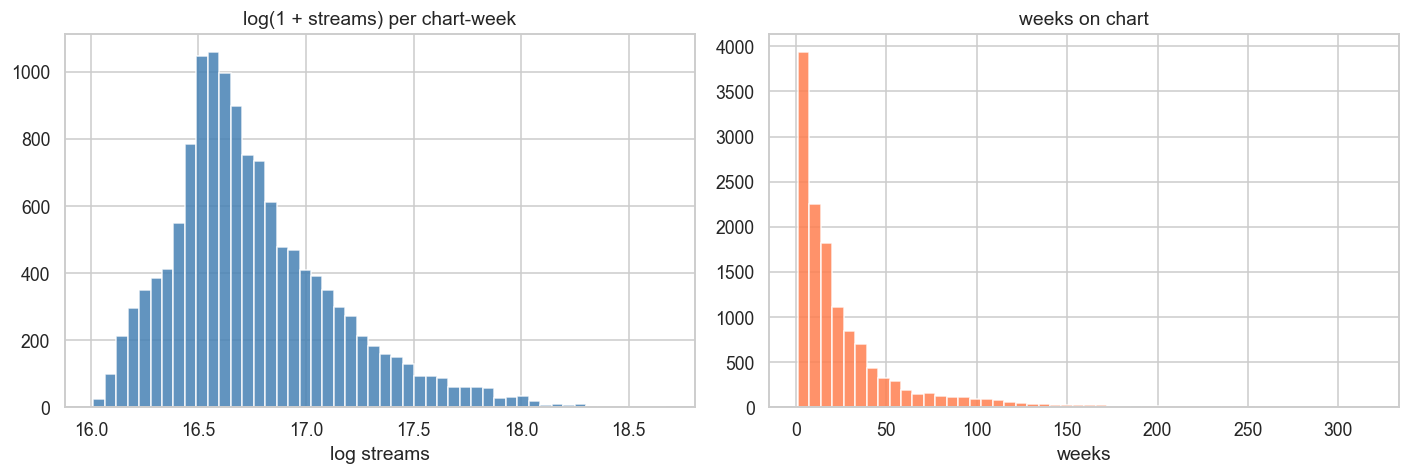

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

df["streams"].dropna().pipe(np.log1p).hist(
    bins=50, ax=axes[0], color="steelblue", edgecolor="white", alpha=0.85,
)
axes[0].set_title("log(1 + streams) per chart-week")
axes[0].set_xlabel("log streams")

df["weeks_on_chart"].dropna().hist(
    bins=50, ax=axes[1], color="coral", edgecolor="white", alpha=0.85,
)
axes[1].set_title("weeks on chart")
axes[1].set_xlabel("weeks")

fig.tight_layout()
plt.show()

**Takeaway.** `streams` is heavily right-skewed even on a log scale, and `weeks_on_chart` is dominated by short-lived tracks. This is *why* H1 and H2 controlled for `streams_first_week`: without it, the regressions would simply be picking up "this song was very popular in week 1."

### 6.2 Audio features vs. chart success — focused correlations

A focused correlation slab lets us see, in one figure, which audio features have any first-order link to the three outcomes we care about.

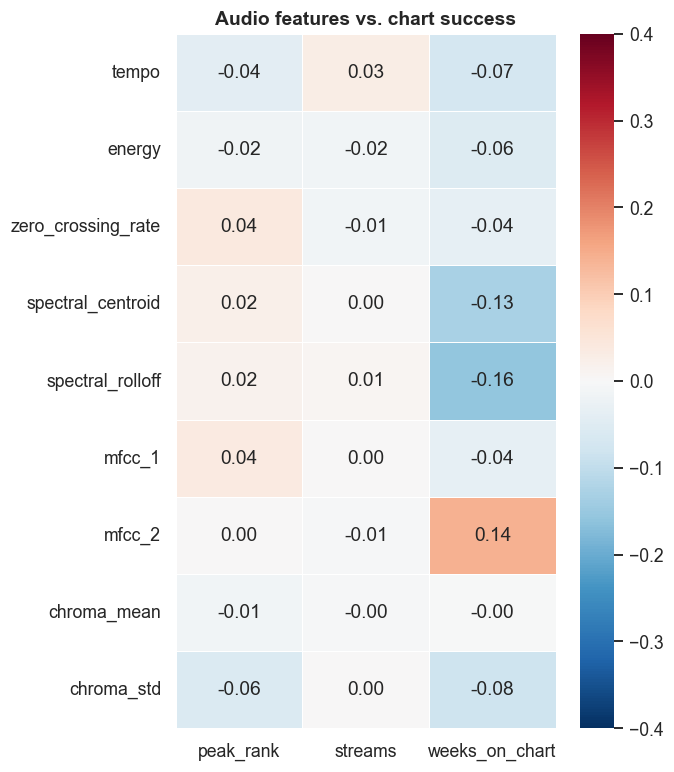

In [12]:
audio_cols = [
    "tempo", "energy", "zero_crossing_rate",
    "spectral_centroid", "spectral_rolloff",
    "mfcc_1", "mfcc_2", "chroma_mean", "chroma_std",
]
target_cols = ["peak_rank", "streams", "weeks_on_chart"]

corr = df[audio_cols + target_cols].corr().loc[audio_cols, target_cols]

fig, ax = plt.subplots(figsize=(6.2, 7.2))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-0.4, vmax=0.4, linewidths=0.5, ax=ax)
ax.set_title("Audio features vs. chart success", fontweight="bold")
fig.tight_layout()
plt.show()

**Takeaway.** All correlations are weak in absolute terms (|r| < 0.15). This is consistent with the regressions in §5: audio characteristics on their own carry only a faint signal about chart performance, which is *why* the brand / collaboration / label questions are interesting.

### 6.3 The "Popularity Premium" — how much of streaming is *not* in the audio?

A simple linear model from the nine audio features to log-streams gives us an upper bound on how much of streaming behaviour the audio alone explains. The residual is what we informally call the *Popularity Premium*: the streams a song gets that its acoustics alone cannot account for.

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

audio_features = [
    "tempo", "energy", "zero_crossing_rate",
    "spectral_centroid", "spectral_rolloff",
    "mfcc_1", "mfcc_2", "chroma_mean", "chroma_std",
]

aud = df.dropna(subset=audio_features + ["streams", "popularity_score"]).copy()
aud["log_streams"] = np.log1p(aud["streams"])

X = StandardScaler().fit_transform(aud[audio_features])
y = aud["log_streams"]

reg = LinearRegression().fit(X, y)
aud["pred_log_streams"] = reg.predict(X)
aud["residual"] = aud["log_streams"] - aud["pred_log_streams"]

r2 = r2_score(y, aud["pred_log_streams"])
print(f"R^2  (audio features -> log streams): {r2:.4f}")
print(f"=> audio features alone explain ~{r2*100:.1f}% of streaming variance")

R^2  (audio features -> log streams): 0.0074
=> audio features alone explain ~0.7% of streaming variance


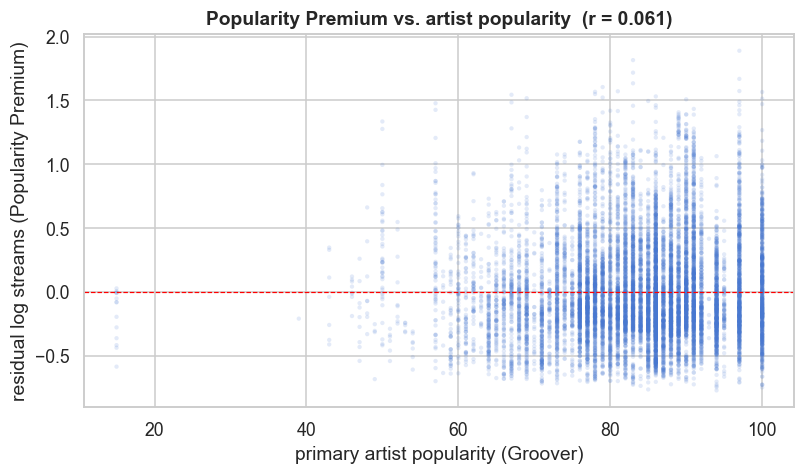

In [14]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.scatter(aud["popularity_score"], aud["residual"],
           alpha=0.15, s=8, edgecolors="none")
ax.axhline(0, color="red", linestyle="--", linewidth=0.8)
r = aud[["popularity_score", "residual"]].corr().iloc[0, 1]
ax.set_title(f"Popularity Premium vs. artist popularity  (r = {r:.3f})",
             fontweight="bold")
ax.set_xlabel("primary artist popularity (Groover)")
ax.set_ylabel("residual log streams (Popularity Premium)")
fig.tight_layout()
plt.show()

**Takeaway.** Audio explains only single-digit percent of variance in `log(streams)`. The residual is positively correlated with artist popularity — i.e. **more popular artists get more streams than their audio “deserves.”** This is the empirical fingerprint of the brand effect that H1 and H2 were trying to isolate, and it is consistent with the pattern we saw in those regressions: once you control for artist popularity and first-week streams, audio and label add relatively little.

## 6.4 Trend analysis : Is the 2024 Audio Features trend spike real, relevant, and who drove It?

In this section, we shift the focus towards understanding trends in aduio features of songs on the Top 50 chart. Are there measurable shifts in audio features (e.g., energy, valence, tempo) that define yearly trends in Spotify Top 50 tracks? and do these patterns vary by year ? 

From the EDA, it shows that standardised audio features peaking in 2024 before falling back in 2025. 
Thus, we focus on investigating 3 layers:

1. Was the spike statistically real? (ANOVA + pairwise t-tests)  
2. Did it correlate with chart success? (high-brightness vs low-brightness in 2024)  
3. Who drove it? (artist-level deep dive)

*  2026 is excluded throughout : the dataset only covers ~7 weeks of 2026 (through 2026-02-19), so its yearly averages are not comparable with full-year figures.

In [28]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from itertools import combinations

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110

DATA   = "data/processed/processed_chart_tracks_enriched_features.csv"
LABELS = "data/raw/raw_unique_source_labeled.csv"

df = pd.read_csv(DATA, parse_dates=["date"])
df["year"] = df["date"].dt.year

print(f"Chart-week rows : {len(df):,}")
print(f"Unique tracks   : {df['uri'].nunique():,}")
print(f"Date range      : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Years present   : {sorted(df['year'].unique())}")

Chart-week rows : 13,399
Unique tracks   : 1,580
Date range      : 2021-01-07 → 2026-02-19
Years present   : [np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025), np.int32(2026)]


In [19]:
AUDIO_TREND_COLS = ["tempo", "energy", "spectral_centroid", "chroma_mean"]
YEARS            = [2021, 2022, 2023, 2024, 2025]

df_full = df[df["year"].isin(YEARS)].copy()
print(f"Rows in 2021–2025 window: {len(df_full):,}")

Rows in 2021–2025 window: 12,999


### 1. Visualization of the Spike

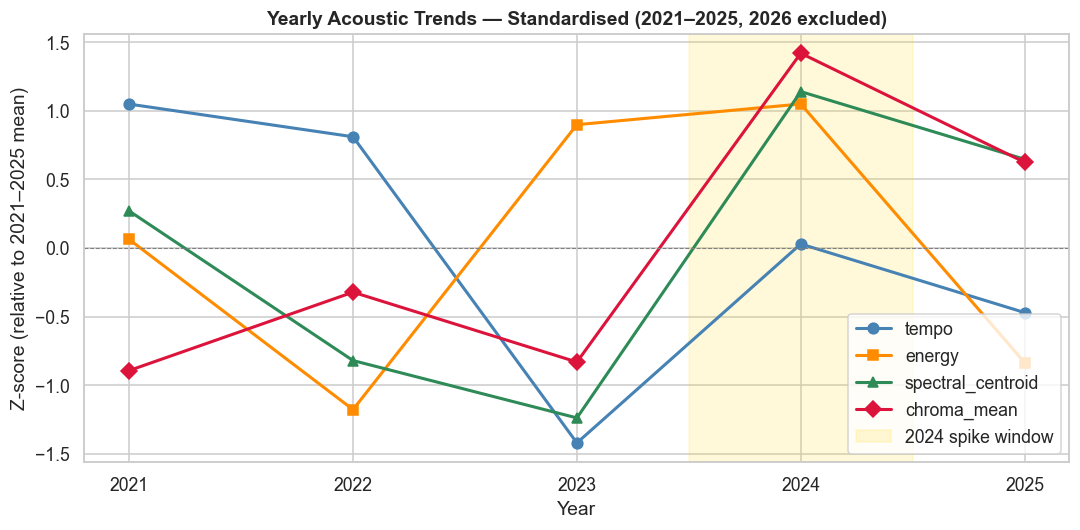

In [ ]:
# from previous EDA (phase 2)
yearly_means = df_full.groupby("year")[AUDIO_TREND_COLS].mean()
yearly_z     = (yearly_means - yearly_means.mean()) / yearly_means.std()

fig, ax = plt.subplots(figsize=(10, 5))
markers = ["o", "s", "^", "D"]
colors  = ["steelblue", "darkorange", "seagreen", "crimson"]

for col, mk, col_c in zip(AUDIO_TREND_COLS, markers, colors):
    ax.plot(YEARS, yearly_z[col], marker=mk, color=col_c,
            linewidth=2, markersize=7, label=col)

ax.axvspan(2023.5, 2024.5, color="gold", alpha=0.15, label="2024 spike window")
ax.axhline(0, color="grey", linewidth=0.7, linestyle="--")
ax.set_xlabel("Year")
ax.set_ylabel("Z-score (relative to 2021–2025 mean)")
ax.set_title("Yearly Acoustic Trends — Standardised (2021–2025, 2026 excluded)",
             fontweight="bold")
ax.legend(loc="lower right")
ax.set_xticks(YEARS)
fig.tight_layout()
plt.show()

### 2. Whether Year-to-Year Variation is statistically real (one-way ANOVA)?

In [21]:
anova_rows = []
for feat in AUDIO_TREND_COLS:
    groups = [grp[feat].dropna().values for _, grp in df_full.groupby("year")]
    F, p   = stats.f_oneway(*groups)
    anova_rows.append({
        "Feature": feat,
        "F-statistic": round(F, 2),
        "p-value": round(p, 6),
        "Significant (α=0.05)": "Yes" if p < 0.05 else "No",
    })

anova_df = pd.DataFrame(anova_rows).set_index("Feature")
print("One-Way ANOVA — Audio Features Across 2021–2025")
print(anova_df.to_string())

One-Way ANOVA — Audio Features Across 2021–2025
                   F-statistic   p-value Significant (α=0.05)
Feature                                                      
tempo                    13.79  0.000000                  Yes
energy                   31.06  0.000000                  Yes
spectral_centroid        12.26  0.000000                  Yes
chroma_mean               7.47  0.000005                  Yes


**Takeaway** : Every feature rejects the null hypothesis (all yearly means equal) at α = 0.05, confirming the year-to-year movement in audio features is not sampling noise. so the next question is "who drove the difference ?"

### 3. Pairwise t-Tests : Pinpointing the 2023 → 2024 Jump

In [22]:
pairs = [(y, y + 1) for y in YEARS[:-1]]
pairwise_rows = []

for feat in AUDIO_TREND_COLS:
    for y1, y2 in pairs:
        g1 = df_full[df_full["year"] == y1][feat].dropna()
        g2 = df_full[df_full["year"] == y2][feat].dropna()
        t, p = stats.ttest_ind(g1, g2)
        pairwise_rows.append({
            "Feature": feat,
            "Transition": f"{y1}→{y2}",
            "t": round(t, 2),
            "p-value": round(p, 4),
            "Significant": "✓" if p < 0.05 else "",
        })

flat = pd.DataFrame(pairwise_rows)
pivot_p   = flat.pivot(index="Transition", columns="Feature", values="p-value")
pivot_sig = flat.pivot(index="Transition", columns="Feature", values="Significant")

print("p-values by consecutive-year transition:")
print(pivot_p.to_string())
print()
print("Significant transitions (α = 0.05):")
print(pivot_sig.to_string())


p-values by consecutive-year transition:
Feature     chroma_mean  energy  spectral_centroid   tempo
Transition                                                
2021→2022        0.2715  0.0000             0.0073  0.5527
2022→2023        0.2975  0.0000             0.2813  0.0000
2023→2024        0.0000  0.5485             0.0000  0.0001
2024→2025        0.1382  0.0000             0.2340  0.1558

Significant transitions (α = 0.05):
Feature    chroma_mean energy spectral_centroid tempo
Transition                                           
2021→2022                   ✓                 ✓      
2022→2023                   ✓                       ✓
2023→2024            ✓                        ✓     ✓
2024→2025                   ✓                        


**Key finding.** The **2023 → 2024** transition is the most significant:
- spectral_centroid (brightness), chroma_mean, tempo show highly significant jumps.
- energy does not change significantly between 2023 and 2024 (p ≈ 0.55)

### 4. Did the Brightness Spike Correlate with Chart Success?

We split 2024 unique tracks into **high** spectral centroid (≥ Q3) and **low** (≤ Q1) groups and compare their chart metrics.

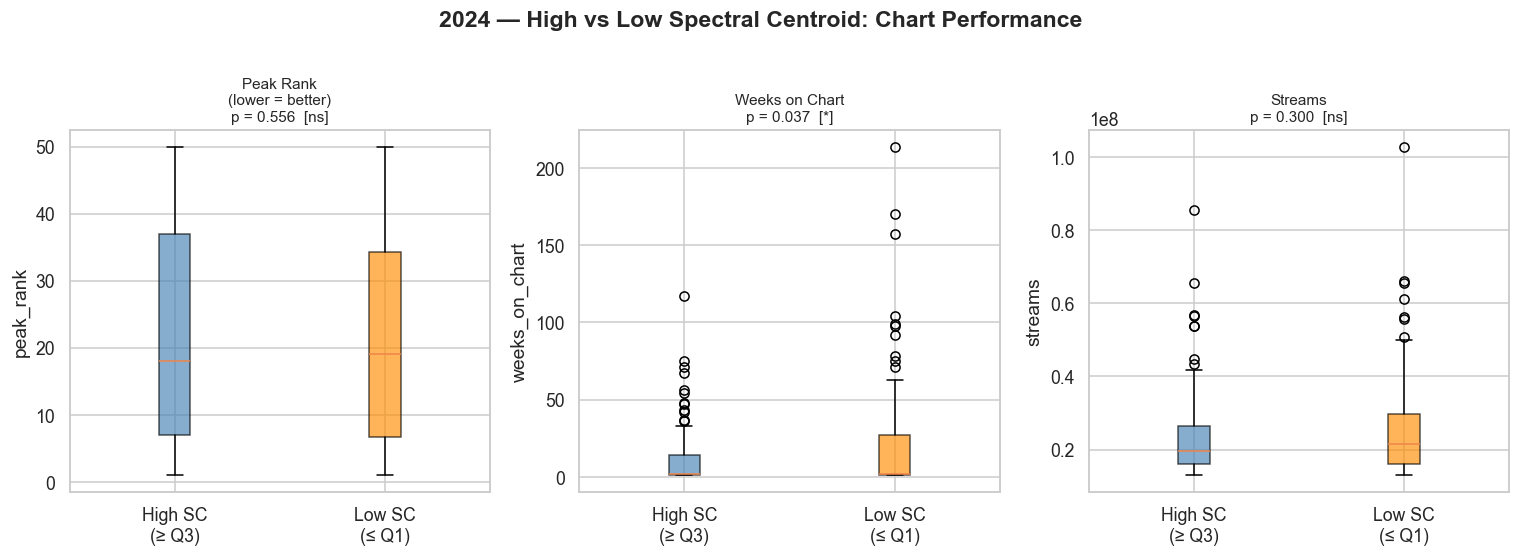

Summary — High SC (≥Q3) vs Low SC (≤Q1) in 2024:
  peak_rank               High=21.9   Low=20.6   p=0.5563
  weeks_on_chart          High=11.9   Low=21.1   p=0.0373
  streams                 High=23858477.7   Low=25854890.1   p=0.2998


In [23]:
df24_songs = (
    df_full[df_full["year"] == 2024]
           .drop_duplicates(subset="uri")
           .copy()
)

q75 = df24_songs["spectral_centroid"].quantile(0.75)
q25 = df24_songs["spectral_centroid"].quantile(0.25)
high_sc = df24_songs[df24_songs["spectral_centroid"] >= q75]
low_sc  = df24_songs[df24_songs["spectral_centroid"] <= q25]

chart_metrics = ["peak_rank", "weeks_on_chart", "streams"]
metric_labels = ["Peak Rank\n(lower = better)", "Weeks on Chart", "Streams"]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, metric, label in zip(axes, chart_metrics, metric_labels):
    data_high = high_sc[metric].dropna()
    data_low  = low_sc[metric].dropna()
    t, p = stats.ttest_ind(data_high, data_low)

    bp = ax.boxplot([data_high, data_low],
                    labels=["High SC\n(≥ Q3)", "Low SC\n(≤ Q1)"],
                    patch_artist=True)
    bp["boxes"][0].set_facecolor("steelblue");  bp["boxes"][0].set_alpha(0.65)
    bp["boxes"][1].set_facecolor("darkorange"); bp["boxes"][1].set_alpha(0.65)

    sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
    ax.set_title(f"{label}\np = {p:.3f}  [{sig}]", fontsize=10)
    ax.set_ylabel(metric)

fig.suptitle("2024 — High vs Low Spectral Centroid: Chart Performance",
             fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

print("Summary — High SC (≥Q3) vs Low SC (≤Q1) in 2024:")
for metric in chart_metrics:
    t, p = stats.ttest_ind(high_sc[metric].dropna(), low_sc[metric].dropna())
    print(f"  {metric:22s}  High={high_sc[metric].mean():.1f}   Low={low_sc[metric].mean():.1f}   p={p:.4f}")


**Takeaway.** High-brightness (high sc) songs in 2024 had significantly **fewer weeks on chart** (~12 vs ~21 weeks, p < 0.05) whil peak ranks and stream counts are very similar (no statistical difference)

### 5. Who Drove the 2024 Spike?

-  we investigate the artistis who has more brighter and trebly songs (high sc)

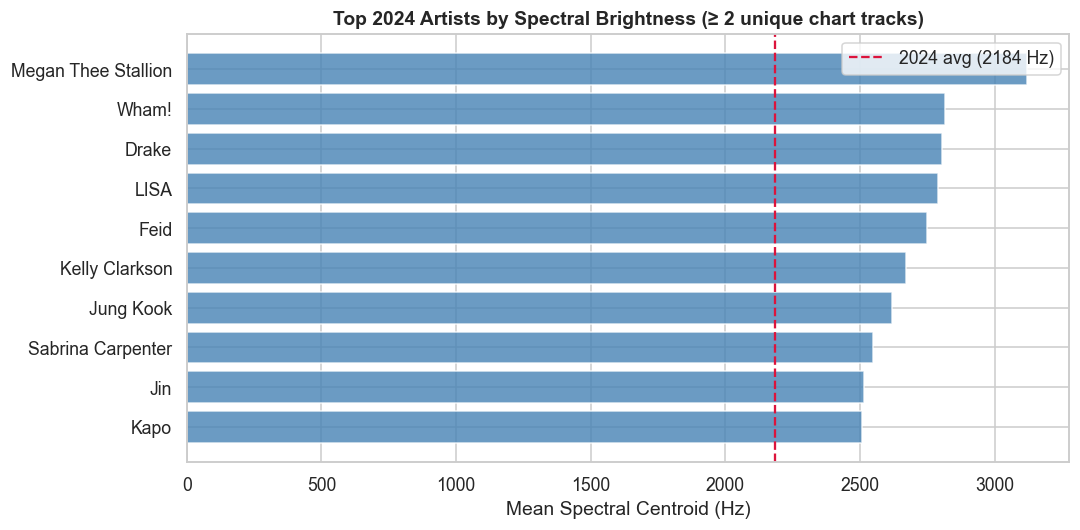

     primary_artist  mean_spectral_centroid  unique_tracks  avg_weeks_on_chart
Megan Thee Stallion             3121.081086              3            1.666667
              Wham!             2815.878841              2           55.000000
              Drake             2805.153937              3            5.333333
               LISA             2788.785457              3            1.000000
               Feid             2749.634964              2            3.000000
     Kelly Clarkson             2671.590666              2           23.500000
          Jung Kook             2618.618640              4           12.250000
  Sabrina Carpenter             2546.267940             16            8.562500
                Jin             2513.222515              3            2.000000
               Kapo             2505.667240              2            3.000000


In [24]:
df24_songs["primary_artist"] = (
    df24_songs["artist_names"].str.split(",").str[0].str.strip()
)

artist_sc = (
    df24_songs.groupby("primary_artist")["spectral_centroid"]
              .agg(mean_sc="mean", track_count="count")
              .query("track_count >= 2")
              .sort_values("mean_sc", ascending=False)
              .head(10)
              .reset_index()
)
artist_weeks = (
    df24_songs.groupby("primary_artist")["weeks_on_chart"]
              .mean()
              .rename("avg_weeks")
)
artist_sc = artist_sc.join(artist_weeks, on="primary_artist")

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(
    artist_sc["primary_artist"][::-1],
    artist_sc["mean_sc"][::-1],
    color="steelblue", alpha=0.8, edgecolor="white"
)
mean_2024 = df24_songs["spectral_centroid"].mean()
ax.axvline(mean_2024, color="crimson", linestyle="--", linewidth=1.5,
           label=f"2024 avg ({mean_2024:.0f} Hz)")
ax.set_xlabel("Mean Spectral Centroid (Hz)")
ax.set_title("Top 2024 Artists by Spectral Brightness (≥ 2 unique chart tracks)",
             fontweight="bold")
ax.legend()
fig.tight_layout()
plt.show()

print(artist_sc[["primary_artist", "mean_sc", "track_count", "avg_weeks"]]
      .rename(columns={"mean_sc": "mean_spectral_centroid",
                       "track_count": "unique_tracks",
                       "avg_weeks": "avg_weeks_on_chart"})
      .to_string(index=False))


**Takeaway :** **Sabrina Carpenter** (16 unique charting tracks, the most of any artist in this segment) is the single dominant driver of the 2024 brightness spike. K-pop acts (LISA, Jung Kook, Jin) reinforce the effect. These are mostly shorter-lived chart entries which is  consistent with the fast-burning pattern identified in §6.4.4. The 2024 spike therefore reflects a **convergence of a dominant pop act and a K-pop wave**, not a broad industry-wide shift in music production.

## 6.5  Temporal Cluster Drift: Do the Sonic "Rules" of Charting Change?

If what makes a song chart-worthy is static, audio clusters should look similar year after year. We test this by fitting K-Means (k = 3) separately within each year, projecting centroids onto a shared PCA space, and tracking how they move.

In [25]:
AUDIO_CLUSTER_COLS = [
    "tempo", "energy", "zero_crossing_rate",
    "spectral_centroid", "spectral_rolloff",
    "mfcc_1", "mfcc_2", "chroma_mean", "chroma_std",
]
K = 3

# Global PCA fitted on all 2021–2025 songs — shared coordinate system
all_songs = (
    df_full.drop_duplicates(subset="uri")
           .dropna(subset=AUDIO_CLUSTER_COLS)
           .copy()
)

scaler_global = StandardScaler()
X_global      = scaler_global.fit_transform(all_songs[AUDIO_CLUSTER_COLS])

pca_global = PCA(n_components=2, random_state=42)
pca_global.fit(X_global)

print(f"Global PCA — PC1: {pca_global.explained_variance_ratio_[0]:.1%} variance | "
      f"PC2: {pca_global.explained_variance_ratio_[1]:.1%} variance")
print(f"Combined: {pca_global.explained_variance_ratio_.sum():.1%}")


Global PCA — PC1: 46.4% variance | PC2: 19.7% variance
Combined: 66.1%


In [26]:
# Per-year K-Means
yearly_results = {}
palette = ["steelblue", "darkorange", "seagreen"]

for yr in YEARS:
    yr_songs = (
        df_full[df_full["year"] == yr]
               .drop_duplicates(subset="uri")
               .dropna(subset=AUDIO_CLUSTER_COLS)
               .copy()
    )
    X_yr = StandardScaler().fit_transform(yr_songs[AUDIO_CLUSTER_COLS])
    km   = KMeans(n_clusters=K, random_state=42, n_init=15)
    yr_songs["cluster"] = km.fit_predict(X_yr)

    # Project centroids onto global PCA space
    centroids_orig = scaler_global.transform(
        yr_songs.groupby("cluster")[AUDIO_CLUSTER_COLS].mean().values
    )
    centroids_pca = pca_global.transform(centroids_orig)

    sil = silhouette_score(X_yr, yr_songs["cluster"])
    yearly_results[yr] = {
        "songs":         yr_songs,
        "centroids_pca": centroids_pca,
        "silhouette":    sil,
    }
    sizes = yr_songs["cluster"].value_counts().sort_index().to_dict()
    print(f"{yr} — silhouette: {sil:.3f}  |  cluster sizes: {sizes}")

2021 — silhouette: 0.195  |  cluster sizes: {0: 143, 1: 110, 2: 124}
2022 — silhouette: 0.197  |  cluster sizes: {0: 136, 1: 152, 2: 100}
2023 — silhouette: 0.179  |  cluster sizes: {0: 162, 1: 150, 2: 86}
2024 — silhouette: 0.198  |  cluster sizes: {0: 89, 1: 111, 2: 187}
2025 — silhouette: 0.223  |  cluster sizes: {0: 119, 1: 116, 2: 83}


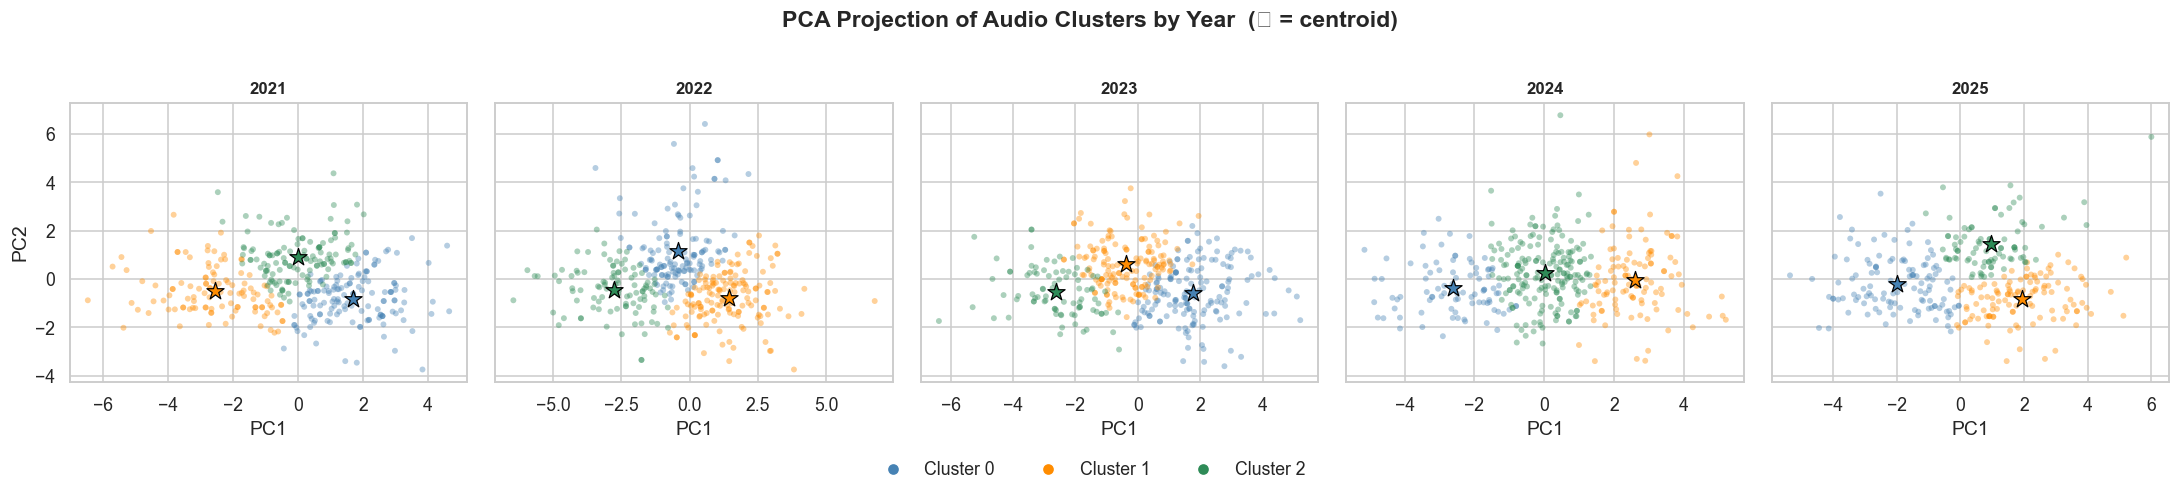

In [27]:
# Plot 1 — PCA scatter per year
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)

for ax, yr in zip(axes, YEARS):
    yr_songs = yearly_results[yr]["songs"].copy()
    X_pca    = pca_global.transform(
        scaler_global.transform(yr_songs[AUDIO_CLUSTER_COLS])
    )
    yr_songs["pc1"] = X_pca[:, 0]
    yr_songs["pc2"] = X_pca[:, 1]

    for c in range(K):
        sub = yr_songs[yr_songs["cluster"] == c]
        ax.scatter(sub["pc1"], sub["pc2"],
                   c=palette[c], alpha=0.4, s=15, edgecolors="none")

    cents = yearly_results[yr]["centroids_pca"]
    for c, (cx, cy) in enumerate(cents):
        ax.scatter(cx, cy, c=palette[c], s=140, marker="*",
                   edgecolors="black", linewidths=0.8, zorder=5)

    ax.set_title(f"{yr}", fontsize=11, fontweight="bold")
    ax.set_xlabel("PC1")
    if yr == YEARS[0]:
        ax.set_ylabel("PC2")

handles = [
    plt.Line2D([0], [0], marker="o", color="w",
               markerfacecolor=palette[c], markersize=8, label=f"Cluster {c}")
    for c in range(K)
]
fig.legend(handles=handles, loc="lower center", ncol=K,
           bbox_to_anchor=(0.5, -0.08), frameon=False)
fig.suptitle("PCA Projection of Audio Clusters by Year  (★ = centroid)",
             fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

**Takeaway** : Cluster centroids shift meaningfully in PCA space, most sharply between 2023 and 2024. the 2024 centroids drift toward higher PC1 (brighter, faster), then partially regress in 2025. The sonic profile of what reaches the Global Top 50 is **not stationary**. This is the cluster-level confirmation of the 2024 spike and supports the overall conclusion: because the audio landscape shifts year-to-year, no single fixed audio profile predicts long-run chart performance.

## 7. Conclusions

| RQ | Hypothesis | Decision | One-line answer |
|----|-----------|----------|-----------------|
| H1 | Collaborations → longer chart life, controlling for first-week streams | **Fail to reject H0** | Once we control for first-week streams and artist popularity, collaborations do not independently extend chart life (β ≈ -0.79, p ≈ 0.25). |
| H2 | Big-3 majors → longer chart life, controlling for streams + audio | **Partially reject H0** | Big-3 *subsidiary* releases last ~1.7 more weeks than independents at equal first-week streams and audio (β ≈ +1.67, p ≈ 0.018); Big-3 *parent* attributions are not significantly different (p ≈ 0.67). |
| H3 | energy × spectral brightness → higher chance of Top-15 peak | **Fail to reject H0** | The energy × brightness interaction does not significantly predict virality (p ≈ 0.39); previous-week rank dominates the model. |

**Bigger picture.** Across all three questions, the overwhelming predictor of chart performance is **prior-week momentum** — `streams_first_week`, `entry_rank_in_top50`, and `previous_rank` dwarf everything else.  

The cleanest non-popularity finding is **H2**: Big-3 *subsidiary* imprints add a small but statistically significant longevity premium (~1.7 weeks) on top of pure first-week streams and audio.   

Collaborations (H1) and the energy-brightness interaction (H3) do not survive the controls. This is consistent with our supplemental Popularity-Premium analysis, which shows that audio features alone explain less than 1% of variance in `log(streams)` and the rest tracks artist-level popularity. Meanwhile, cluster centroids drift year-to-year in PCA space, meaning sonic rule are not fixed. Audio features capture who is dominating the chart in a given year, not what makes a song stay.

## 8. Limitations

- **Selection on the dependent variable.** Our population is "songs that already reached the Global Top 50." We cannot learn what stops a song from charting at all — only what differentiates short-lived chart entries from long-lived ones.
- **Audio features come from YouTube, not Spotify.** Spotify's `audio_analysis` endpoint was deprecated in late 2024, so we substituted YouTube audio + `librosa`. YouTube uploads are sometimes not the canonical mix (live versions, sped-up edits), which adds noise to every audio feature.
- **`monthly_listeners` is current, not historical.** kworb only publishes a snapshot, so a 2021 track is being matched to its 2026 monthly-listener count. We use it as a proxy for artist stature, not as a time-aligned exposure measure.
- **Label classification is hand-coded.** The `source` field is a free-text label string with hundreds of variants. We mapped each unique string to `{Big-3 parent, Big-3 subsidiary, independent}` by hand, which is reproducible but not exhaustive — distributor-style strings are bucketed as "independent" and may include majors-distributed releases.
- **Possible harms.** Findings here could be misread as prescriptive ("make a track that sounds like X to go viral"). They are descriptive at best, the sample is global-mainstream and English-skewed, and any deployment to recommend music must consider equity impacts on smaller-market artists.

## 9. Acknowledgements & Bibliography

**Data sources**
- Spotify Charts. Global Weekly Top 50, 2021–2026. https://charts.spotify.com
- kworb.net. Spotify Monthly Listeners. https://kworb.net/spotify/listeners.html
- Groover. Spotify Popularity Score. https://groover.co/en/lp/free-tools/spotify-popularity-score/

**Tools**
- `librosa` — audio feature extraction.
- `yt-dlp` — audio retrieval from YouTube.
- `pandas`, `numpy`, `statsmodels`, `scikit-learn`, `matplotlib`, `seaborn` — data wrangling, modelling, and visualisation.
- `Selenium` + `webdriver-manager` — chart scraping.

**Literature**
- Interiano, M., Kazemi, K., Wang, L., Yang, J., Yu, Z., & Komarova, N. L. (2018). *Musical trends and predictability of success in contemporary songs in and out of the top charts.* Royal Society Open Science, 5(5).
- IFPI. (2023). *Global Music Report 2023.* International Federation of the Phonographic Industry.
- Music Business Worldwide. (2023). Coverage of collaboration trends in the streaming era.

**Acknowledgements**
- Thanks to all the TAs for Phase 1–3 feedback that materially reshaped our preregistration (in particular, the suggestion to add `popularity_score` and `previous_rank` as controls).